# Assessing Bicycle Lane Quality Using Smartphone Sensor Data

This notebook contains the complete data analysis pipeline for
classifying bicycle-lane sections as Smooth or Bumpy using
smartphone sensor data.

The analysis includes data loading, preprocessing, feature
extraction, feature selection, supervised and unsupervised
learning, model evaluation, and deployment.

> **Group members:**
>
> | Name | Student number |
> |---|---|
> | Himanshu Khartade | 2431459 |
> | Aniket Zade | 2431491 |
> | Yuhan Shao | 2034964 |
>
> Participants are referred to as **P1, P2, P3** everywhere else (data files, plots, text) to keep the data anonymous.

# Environment and Reproducibility
The Python environment and package versions are recorded below to
support reproducibility.

In [99]:
import sys

import pandas as pd
import numpy as np
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
import seaborn as sns

print("Python version:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
pandas: 2.2.3
numpy: 2.3.5
scikit-learn: 1.9.0
matplotlib: 3.10.0


# Study Design & Data Collection

**Aim** Build a tool that classifies bike-lane surface quality — *smooth* or *bumpy* — from the motion sensors of a
smartphone.

**Participants** 3 group members (P1-P3), all course participants who can bike and have no condition that prevents
cycling. Every participant recorded one smooth and one bumpy ride.

**Sensors & settings** Sensor Logger app; accelerometer, gyroscope and gravity sensor only (all other sensors
off); default 100 Hz; *Standardisation* option on so iOS and Android exports are comparable.

**Procedure** Start recording → put the phone on the basket → ride the lane continuously → stop → take
the phone out → stop recording. Lane choice followed the protocol: *smooth* = a typical red cycling lane without imperfections;
*bumpy* = a commonly used lane with noticeable but not dangerous imperfections (small potholes, cracks, uneven surface).

**Data management**
- `data/raw/` — untouched exports, one folder per participant and condition, consistent names, anonymized (P1-P3).
- `data/processed/` — everything the notebook derives (merged + trimmed recordings, window features), stored separately.

In [34]:
def load_and_merge(acc_path, grav_path, gyro_path):
    """
    Load accelerometer, gravity, and gyroscope data and combine
    them using their timestamps.
    """

    acc = pd.read_csv(acc_path).rename(
        columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'}
    )

    grav = pd.read_csv(grav_path).rename(
        columns={'x': 'grav_x', 'y': 'grav_y', 'z': 'grav_z'}
    )

    gyro = pd.read_csv(gyro_path).rename(
        columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'}
    )

    # Check that all recordings have the same number of observations
    if not (len(acc) == len(grav) == len(gyro)):
        raise ValueError("Sensor files have different numbers of rows.")

    # Check timestamp alignment
    if not acc['time'].equals(grav['time']):
        raise ValueError("Accelerometer and gravity timestamps are not aligned.")

    if not acc['time'].equals(gyro['time']):
        raise ValueError("Accelerometer and gyroscope timestamps are not aligned.")

    # Combine the sensor measurements
    df = acc[
        ['time', 'seconds_elapsed', 'acc_x', 'acc_y', 'acc_z']
    ].copy()

    df[['grav_x', 'grav_y', 'grav_z']] = grav[
        ['grav_x', 'grav_y', 'grav_z']
    ]

    df[['gyro_x', 'gyro_y', 'gyro_z']] = gyro[
        ['gyro_x', 'gyro_y', 'gyro_z']
    ]

    return df


In [35]:
# Define the location of each participant's recordings

recordings = {
    'P1_smooth': {
        'label': 'smooth',
        'folder': 'data_raw/Smooth/P1'
    },
    'P1_bumpy': {
        'label': 'bumpy',
        'folder': 'data_raw/Bumpy/P1'
    },
    'P2_smooth': {
        'label': 'smooth',
        'folder': 'data_raw/Smooth/P2'
    },
    'P2_bumpy': {
        'label': 'bumpy',
        'folder': 'data_raw/Bumpy/P2'
    },
    'P3_smooth': {
        'label': 'smooth',
        'folder': 'data_raw/Smooth/P3'
    },
    'P3_bumpy': {
        'label': 'bumpy',
        'folder': 'data_raw/Bumpy/P3'
    }
}

In [36]:
# Dictionary to store the merged data for each recording
merge_recordings = {}

for name, recording in recordings.items():

    folder = recording['folder']

# Load and merge accelerometer, gravity, and gyroscope data
    df = load_and_merge(
        f"{folder}/Accelerometer.csv",
        f"{folder}/Gravity.csv",
        f"{folder}/Gyroscope.csv")

# Store the merged data using the recording name
    merge_recordings[name] = df
    
# Display the number of samples and recording duration
    print(
        f"{name}: "
        f"{len(df)} rows, "
        f"{df['seconds_elapsed'].max():.1f} seconds"
    )

P1_smooth: 33176 rows, 332.2 seconds
P1_bumpy: 50749 rows, 508.1 seconds
P2_smooth: 49779 rows, 501.8 seconds
P2_bumpy: 50613 rows, 510.2 seconds
P3_smooth: 55894 rows, 561.1 seconds
P3_bumpy: 57708 rows, 579.3 seconds


## 3. Data Quality Assessment & Exploratory Data Analysis

Before any modeling: is the data complete and regular, and do the rides look like what they are supposed to be?

Per recording: sample count, duration, effective sampling rate, largest gap between samples, missing values and duplicated
timestamps. (Timestamp alignment of the three sensors was already asserted while loading.)

In [63]:
def recording_quality(key, df):
    t = df['seconds_elapsed'].values

    participant = key.split('_')[0]

    # Return a dictionary containing metadata and calculated quality metrics
    return {
        'recording': key,
    
        'participant':participant,

        'rows': len(df),
        # Calculate total duration in seconds (last timestamp minus first timestamp)
        'duration_s': round(t[-1] - t[0], 1),

        # Calculate effective sampling frequency (Hz): (Total intervals) / (Total duration)
        'effective_hz': round((len(t) - 1) / (t[-1] - t[0]), 1),

        # Count the total number of missing (NaN) values across all columns in the DataFrame
        'missing_values': int(df.isna().sum().sum()),

        # Count how many timestamps in the 'time' column are exact duplicates
        'duplicate_timestamps': int(df['time'].duplicated().sum()),
    }

# Create a summary DataFrame aggregating the quality metrics for all recordings
quality = pd.DataFrame(
    [recording_quality(name, df)
        for name, df in merge_recordings.items()
    ]).set_index('recording')

display(quality)

total_dur = round(quality['duration_s'].sum() / 60,2)
print(f'Total duration: {total_dur} mins')

,participant,rows,duration_s,effective_hz,missing_values,duplicate_timestamps
recording,,,,,,
P1_smooth,P1,33176,332.1,99.9,0,0
P1_bumpy,P1,50749,508.1,99.9,0,0
P2_smooth,P2,49779,501.7,99.2,0,0
P2_bumpy,P2,50613,510.1,99.2,0,0
P3_smooth,P3,55894,561.0,99.6,0,0
P3_bumpy,P3,57708,579.3,99.6,0,0


Total duration: 49.87 mins


# Data Preprocessing

In [38]:
# Calculate the overall acceleration magnitude
def signal_summary(df):
    magnitude = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

    return {
        'std': magnitude.std(),
        'max': magnitude.max()
    }

rows = {}

for name, df in merge_recordings.items():
    rows[name] = signal_summary(df)


magnitude_quality = (
    pd.DataFrame(rows).round(2)
    )

display(magnitude_quality)

,P1_smooth,P1_bumpy,P2_smooth,P2_bumpy,P3_smooth,P3_bumpy
std,1.33,1.92,1.11,1.90,2.47,5.59
max,51.38,28.03,24.60,27.42,53.40,88.72


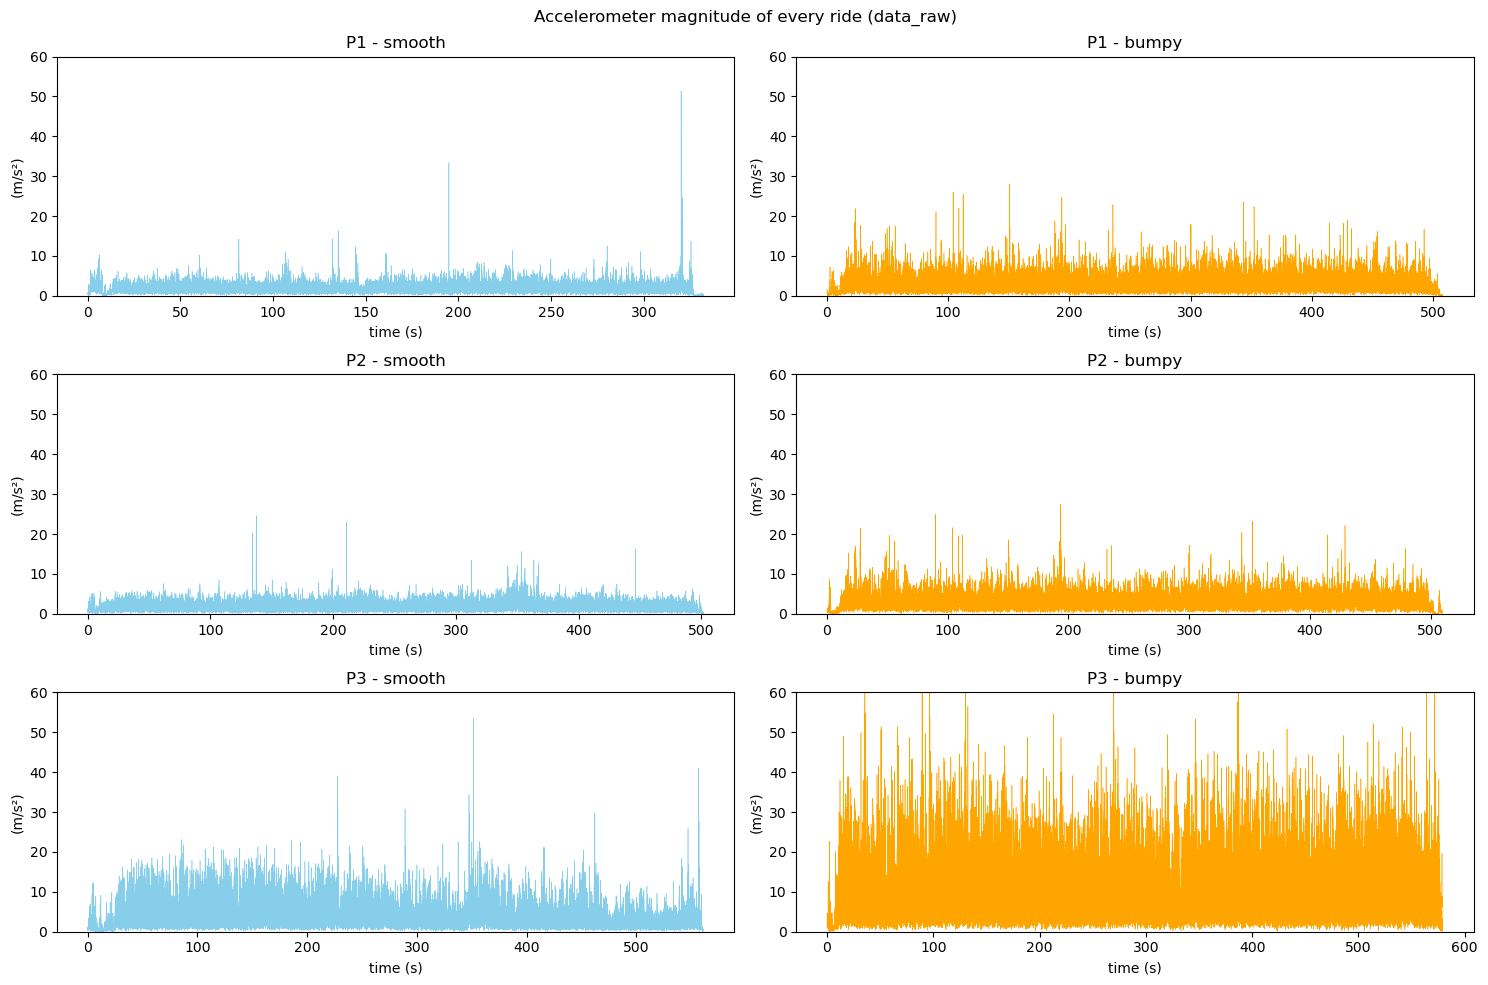

In [39]:
#Visualization of accelerometer magnitude of every ride

fig, axes = plt.subplots(3, 2, figsize=(15, 10))

for i, participant in enumerate(['P1', 'P2', 'P3']):

    for j, label in enumerate(['smooth', 'bumpy']):

        df = merge_recordings[f'{participant}_{label}']
        magnitude = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

        if label == 'smooth':color = 'skyblue' 
        else:color = 'orange'
        
        axes[i,j].plot(df['seconds_elapsed'], magnitude, color, lw = 0.4)
        axes[i, j].set_title(f'{participant} - {label}')
        axes[i, j].set_ylim(0, 60)
        axes[i, j].set_ylabel('(m/s²)')
        axes[i, j].set_xlabel('time (s)')


plt.suptitle('Accelerometer magnitude of every ride (data_raw)')
plt.tight_layout()
plt.show()


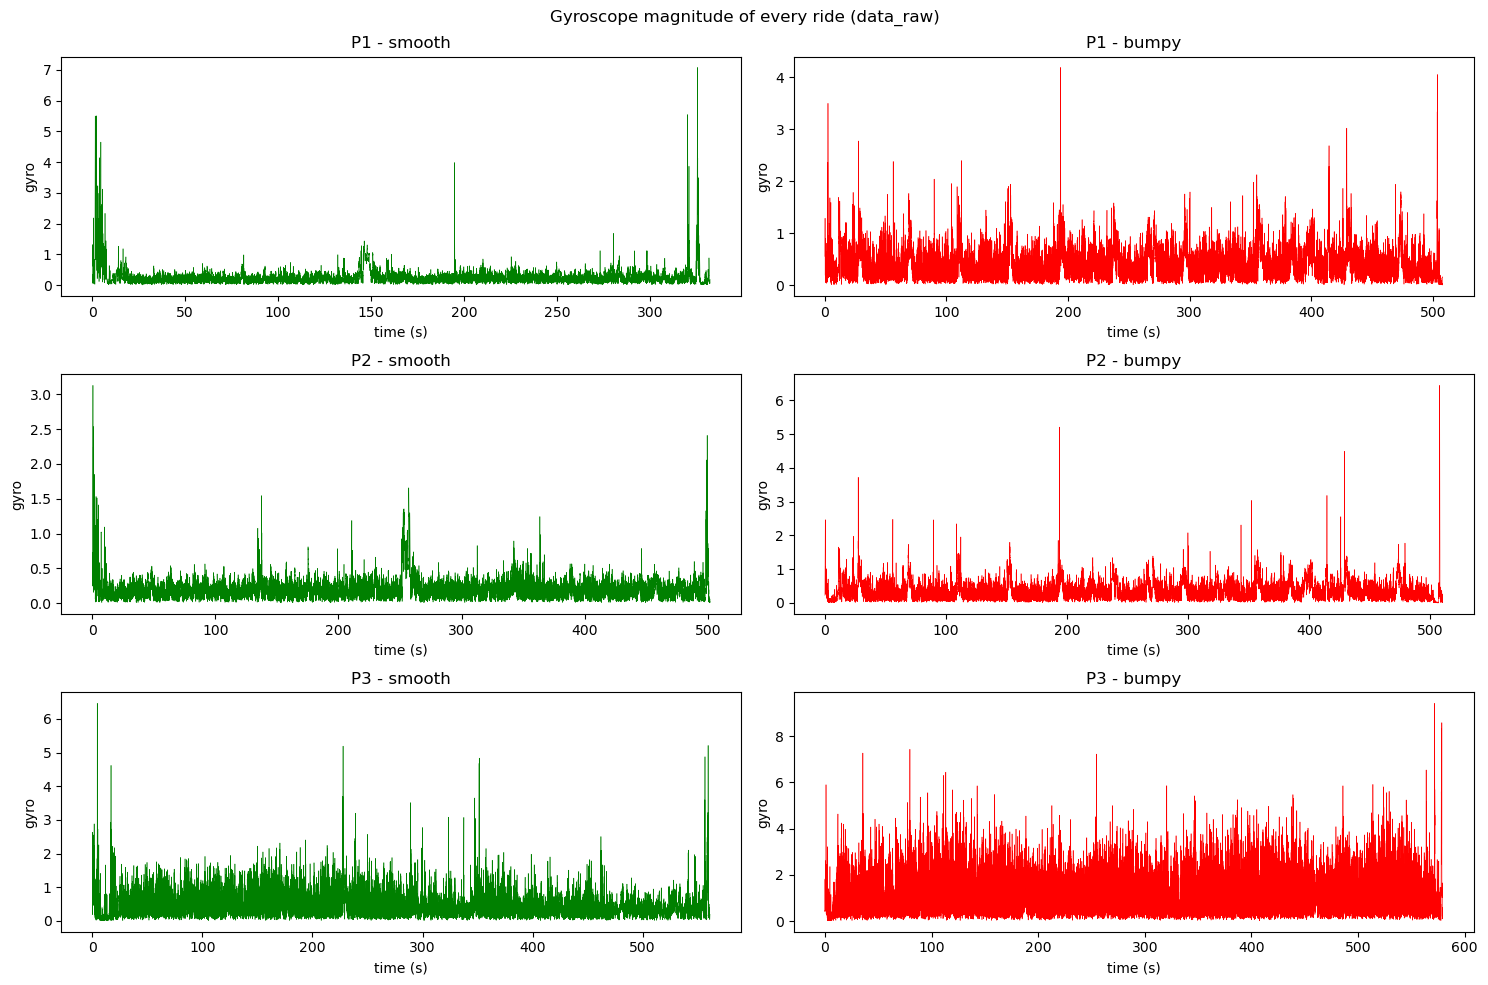

In [40]:
#Visualization of gyroscope magnitude of every ride

fig, axes = plt.subplots(3, 2, figsize=(15, 10))

for i, participant in enumerate(['P1', 'P2', 'P3']):

    for j, label in enumerate(['smooth', 'bumpy']):

        df = merge_recordings[f'{participant}_{label}']
        magnitude = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)

        if label == 'smooth':color = 'green' 
        else:color = 'red'
        
        axes[i,j].plot(df['seconds_elapsed'], magnitude, color, lw = 0.4)
        axes[i, j].set_title(f'{participant} - {label}')
        axes[i, j].set_ylabel('gyro')
        axes[i, j].set_xlabel('time (s)')


plt.suptitle('Gyroscope magnitude of every ride (data_raw)')
plt.tight_layout()
plt.show()

# Feature Engineering & Extraction

**Windowing strategy**

In [41]:
Sampling_freq = 100
steps = 1
windows = 2

window_size = Sampling_freq * windows
step_size = Sampling_freq * steps

def create_window(df, window_size, step_size):
    windows_data = []

    for right in range (0, len(df)-window_size+1, step_size):
        left = right + window_size
        windows_data.append(df.iloc[right:left].copy())
    return windows_data

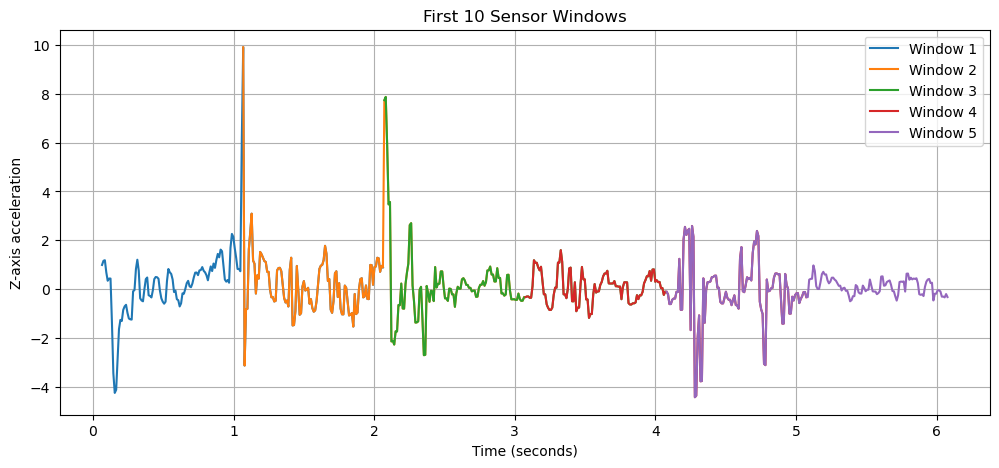

In [78]:
windows_data = create_window(df, window_size, step_size)

# Plot the first 10 windows
plt.figure(figsize=(12, 5))

for i, window in enumerate(windows_data[:5]):
    plt.plot(
        window["seconds_elapsed"],
        window["acc_x"],
        label=f"Window {i+1}"
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Z-axis acceleration")
plt.title("First 10 Sensor Windows")
plt.legend()
plt.grid(True)
plt.show()

In [71]:
for name, df in merge_recordings.items():
    participant_windows = create_window(df, window_size, step_size)
    print(name," |rows-", len(df), " |duration-", round(df['seconds_elapsed'].iloc[-1],2), " |windows-",len(participant_windows))


P1_smooth  |rows- 33176  |duration- 332.21  |windows- 330
P1_bumpy  |rows- 50749  |duration- 508.12  |windows- 506
P2_smooth  |rows- 49779  |duration- 501.76  |windows- 496
P2_bumpy  |rows- 50613  |duration- 510.17  |windows- 505
P3_smooth  |rows- 55894  |duration- 561.1  |windows- 557
P3_bumpy  |rows- 57708  |duration- 579.33  |windows- 576


**Feature Extraction**

In [72]:
def extract_features(window):
    acc_magnitude = np.sqrt(window['acc_x']**2 + window['acc_y']**2 + window['acc_z']**2)
    grav_magnitude = np.sqrt(window['grav_x']**2+window['grav_y']**2+window['grav_z']**2)
    gyro_magnitude = np.sqrt(window['gyro_x']**2+window['gyro_y']**2+window['gyro_z']**2)

    features = {
        # Accelerometer
        'acc_std': acc_magnitude.std(),
        'acc_mean': acc_magnitude.mean(),
        'acc_rms': np.sqrt(np.mean(acc_magnitude**2)),
        'acc_min': acc_magnitude.min(),
        'acc_max': acc_magnitude.max(),

        # Gyroscope
        'gyro_std': gyro_magnitude.std(),
        'gyro_mean': gyro_magnitude.mean(),
        'gyro_rms': np.sqrt(np.mean(gyro_magnitude**2)),
        'gyro_min': gyro_magnitude.min(),
        'gyro_max': gyro_magnitude.max(),

        # Gravity
        'grav_std': grav_magnitude.std(),
        'grav_mean': grav_magnitude.mean(),
        'grav_rms': np.sqrt(np.mean(grav_magnitude**2)),
        'grav_min': grav_magnitude.min(),
        'grav_max': grav_magnitude.max()
    }

    return features

    

In [73]:
#Features dataframe showing mean, standard deviation, minimum, maximun and root mean square
feature_data = []

for header, df in merge_recordings.items():
    participant, label = header.split('_')
    participant_windows = create_window(df, window_size, step_size)
    
    for window_id, window in enumerate(participant_windows):
        feature = extract_features(window)
        feature['Window_id'] = window_id
        feature['participant'] = participant
        feature['label'] = label

        feature_data.append(feature)

feature_df = pd.DataFrame(feature_data)
print(feature_df.head())
print('\n',feature_df.shape)
print('\n', feature_df['label'].value_counts)


    acc_std  acc_mean   acc_rms   acc_min   acc_max  gyro_std  gyro_mean  \
0  1.463881  1.374221  2.005173  0.109140  6.402666  1.300457   1.083825   
1  1.525495  2.489323  2.917572  0.223551  6.402666  1.471055   1.978082   
2  1.292867  3.123863  3.379596  0.870259  6.498721  1.191529   1.916464   
3  1.339164  2.649562  2.967250  0.380867  6.498721  0.858917   1.341099   
4  1.624434  2.646282  3.102966  0.380867  9.235902  0.656756   1.135318   

   gyro_rms  gyro_min  gyro_max      grav_std  grav_mean  grav_rms  grav_min  \
0  1.690387  0.023482  5.498241  3.207383e-07    9.80665   9.80665  9.806649   
1  2.462923  0.023482  5.503100  5.327922e-07    9.80665   9.80665  9.806648   
2  2.255100  0.112729  5.503100  6.699135e-07    9.80665   9.80665  9.806648   
3  1.591413  0.112729  4.649344  6.732753e-07    9.80665   9.80665  9.806648   
4  1.310770  0.095997  4.649344  7.374127e-07    9.80665   9.80665  9.806648   

   grav_max  Window_id participant   label  
0  9.806651      

In [45]:
#Converting features into X and y variables to create a trainable dataset
X_feature_ext = ['acc_std','acc_mean','acc_rms','acc_min','acc_max',
                  'gyro_std','gyro_mean','gyro_rms','gyro_min','gyro_max',
                  'grav_std','grav_mean','grav_rms','grav_min','grav_max']

X_features = feature_df[X_feature_ext]
y_feature = feature_df['label']

print("X shape:", X_features.shape)
print("y shape:", y_feature.shape)


X shape: (2970, 15)
y shape: (2970,)


In [46]:
#Correlation between features
corr  = X_features.corr()
display(corr.round(2))

,acc_std,acc_mean,acc_rms,acc_min,acc_max,gyro_std,gyro_mean,gyro_rms,gyro_min,gyro_max,grav_std,grav_mean,grav_rms,grav_min,grav_max
acc_std,1.00,0.97,0.99,0.75,0.97,0.88,0.90,0.90,0.36,0.89,-0.43,0.40,0.40,0.46,-0.31
acc_mean,0.97,1.00,0.99,0.79,0.92,0.83,0.89,0.88,0.40,0.83,-0.41,0.37,0.37,0.45,-0.31
acc_rms,0.99,0.99,1.00,0.78,0.95,0.86,0.90,0.89,0.39,0.86,-0.42,0.39,0.39,0.46,-0.31
acc_min,0.75,0.79,0.78,1.00,0.71,0.64,0.72,0.70,0.34,0.64,-0.31,0.29,0.29,0.35,-0.23
acc_max,0.97,0.92,0.95,0.71,1.00,0.88,0.87,0.88,0.35,0.89,-0.41,0.40,0.40,0.45,-0.29
gyro_std,0.88,0.83,0.86,0.64,0.88,1.00,0.94,0.97,0.36,0.97,-0.43,0.40,0.40,0.44,-0.28
gyro_mean,0.90,0.89,0.90,0.72,0.87,0.94,1.00,0.99,0.55,0.92,-0.44,0.40,0.40,0.45,-0.31
gyro_rms,0.90,0.88,0.89,0.70,0.88,0.97,0.99,1.00,0.51,0.95,-0.44,0.41,0.41,0.45,-0.30
gyro_min,0.36,0.40,0.39,0.34,0.35,0.36,0.55,0.51,1.00,0.38,-0.19,0.17,0.17,0.18,-0.13
gyro_max,0.89,0.83,0.86,0.64,0.89,0.97,0.92,0.95,0.38,1.00,-0.43,0.40,0.40,0.45,-0.29


**Feature Selection**

Feature selection is the important process in the feature engineering.
As seen in the above output gravity features were not making any difference in dataset, their varaince was very low
We are choosing only the features which shows variance and correlation

In [ ]:
X_feature_selection = [
    'acc_std','acc_mean','acc_rms','acc_min','acc_max',
    'gyro_std','gyro_mean','gyro_rms','gyro_min','gyro_max'
]

X_features_selected = feature_df[X_feature_selection]
y_feature_selected = feature_df['label']

print("X shape:", X_features_selected.shape)
print("y shape:", y_feature_selected.shape)

X shape: (2970, 10)
y shape: (2970,)


In [48]:
#Correlation between features
corr  = X_features_selected.corr()
display(corr.round(2))

,acc_std,acc_mean,acc_rms,acc_min,acc_max,gyro_std,gyro_mean,gyro_rms,gyro_min,gyro_max
acc_std,1.00,0.97,0.99,0.75,0.97,0.88,0.90,0.90,0.36,0.89
acc_mean,0.97,1.00,0.99,0.79,0.92,0.83,0.89,0.88,0.40,0.83
acc_rms,0.99,0.99,1.00,0.78,0.95,0.86,0.90,0.89,0.39,0.86
acc_min,0.75,0.79,0.78,1.00,0.71,0.64,0.72,0.70,0.34,0.64
acc_max,0.97,0.92,0.95,0.71,1.00,0.88,0.87,0.88,0.35,0.89
gyro_std,0.88,0.83,0.86,0.64,0.88,1.00,0.94,0.97,0.36,0.97
gyro_mean,0.90,0.89,0.90,0.72,0.87,0.94,1.00,0.99,0.55,0.92
gyro_rms,0.90,0.88,0.89,0.70,0.88,0.97,0.99,1.00,0.51,0.95
gyro_min,0.36,0.40,0.39,0.34,0.35,0.36,0.55,0.51,1.00,0.38
gyro_max,0.89,0.83,0.86,0.64,0.89,0.97,0.92,0.95,0.38,1.00


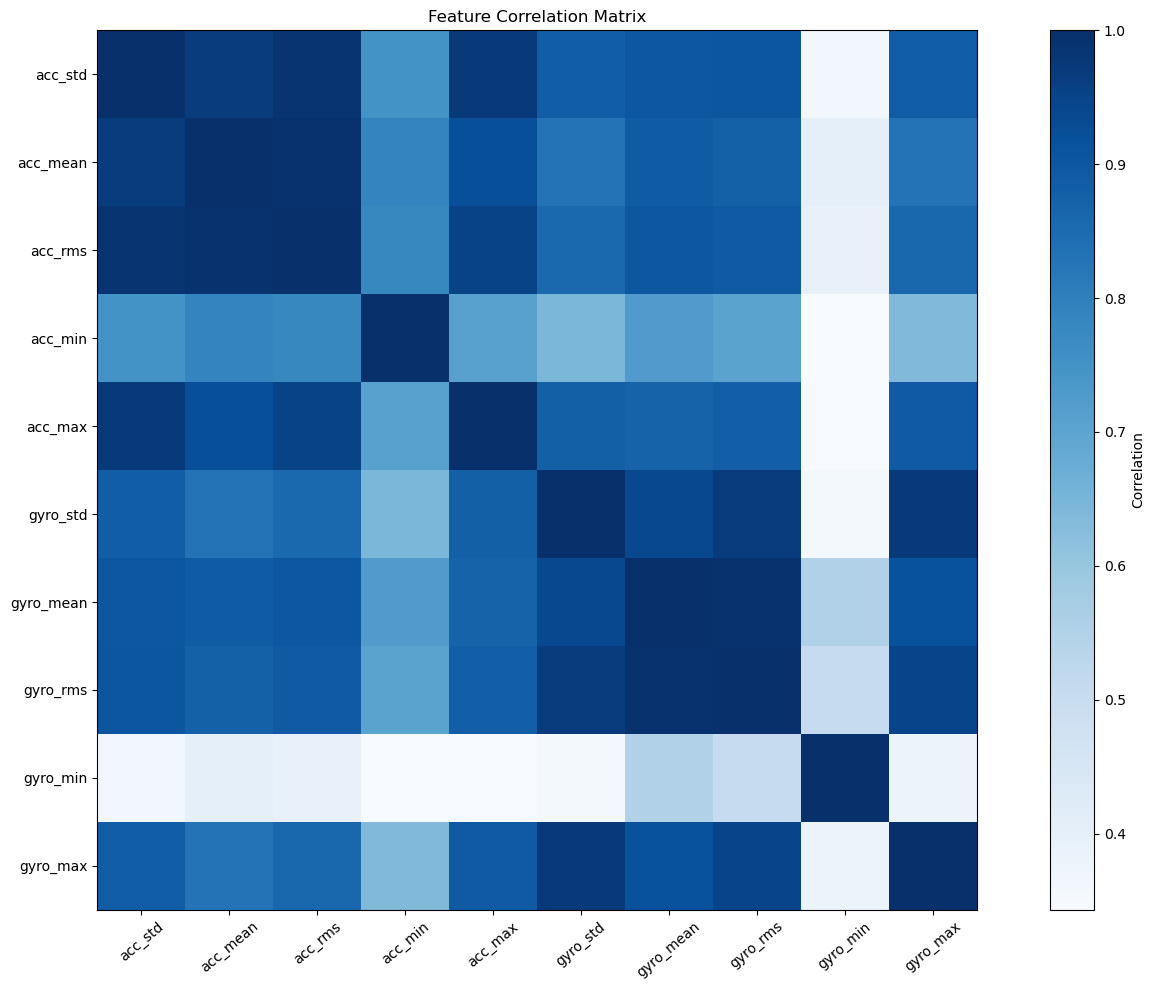

In [49]:
#Visualization of correlation 
plt.figure(figsize=(15, 10))

plt.imshow(corr, cmap='Blues')

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=40,
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar(label='Correlation')
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

Mutual Information

In [50]:
from sklearn.feature_selection import mutual_info_classif

y_num = y_feature_selected.map({
    'smooth':0,
    'bumpy':1
})

mi = mutual_info_classif(X_features_selected, y_feature_selected, random_state=42)

mi_df = pd.DataFrame({
    'Feature':X_features_selected.columns,
    'Mutual information': mi}
)

mi_df = mi_df.sort_values('Mutual information', ascending=False)

display(mi_df.round(2))

,Feature,Mutual information
4,acc_max,0.34
1,acc_mean,0.34
2,acc_rms,0.33
9,gyro_max,0.33
0,acc_std,0.31
5,gyro_std,0.25
3,acc_min,0.23
7,gyro_rms,0.23
6,gyro_mean,0.22
8,gyro_min,0.19


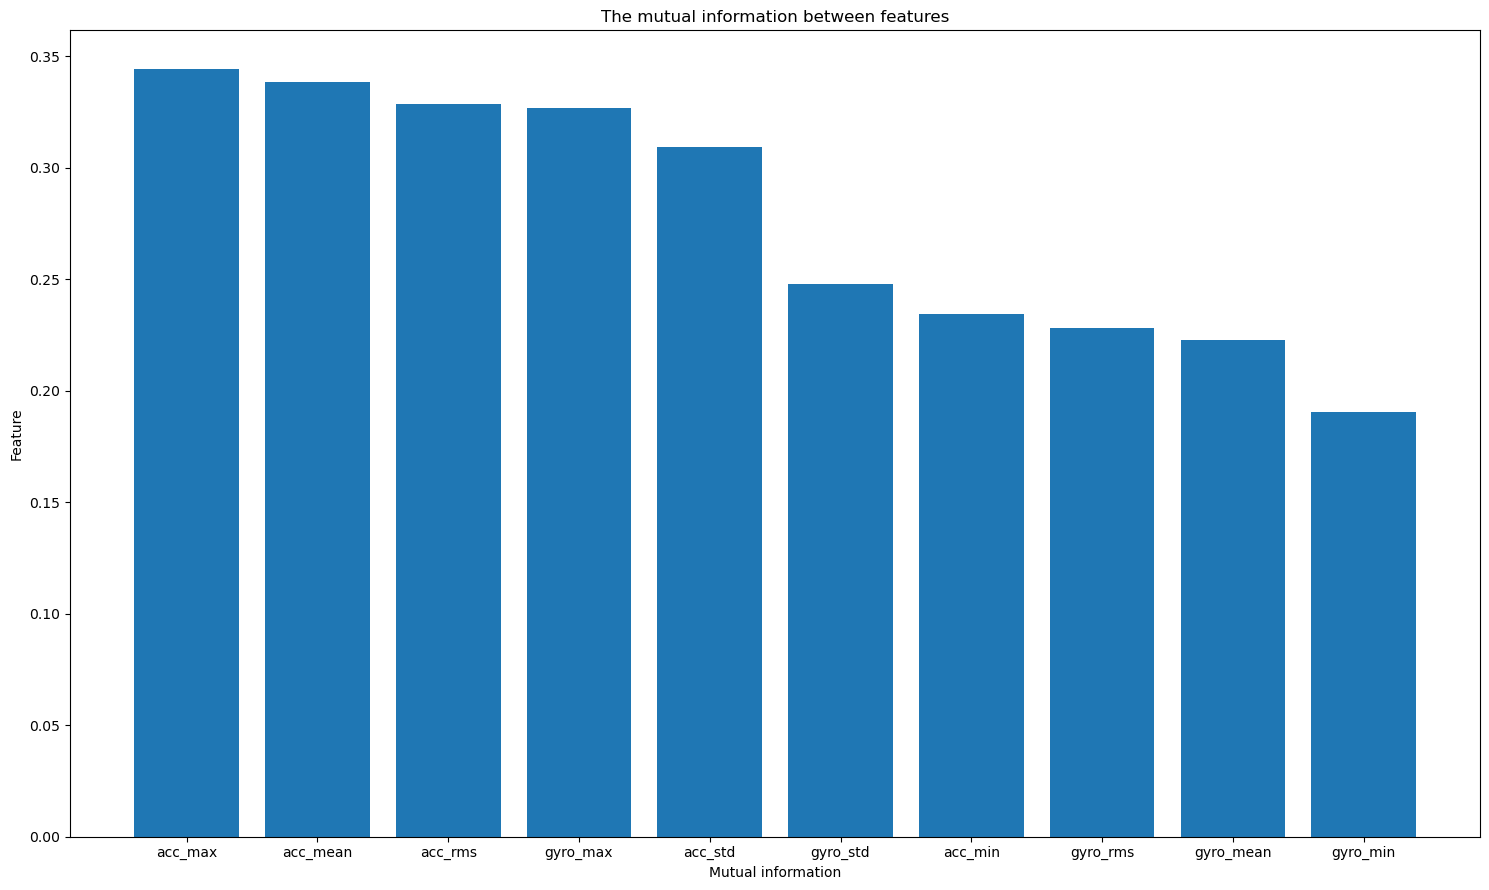

In [51]:
#Visualize the mutual information between features
plt.figure(figsize=(15,9))

plt.bar(mi_df['Feature'],mi_df['Mutual information'])

plt.xlabel('Mutual information')
plt.ylabel('Feature')
plt.title('The mutual information between features')

plt.tight_layout()
plt.show()



# Supervised Learning

Building pipeline of supervised models

In [93]:
def build_supervised_model(model, model_name):

        X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.3, random_state=42)
        #Scale the data 
        sc = StandardScaler()

        X_train_sc = sc.fit_transform(X_train)
        X_test_sc = sc.transform(X_test)

        #Apply PCA in training set
        pca = PCA(n_components=0.95) #varaince at 95%

        X_train_pca = pca.fit_transform(X_train_sc)
        X_test_pca = pca.transform(X_test_sc)

        #Model training 
        model.fit(X_train_pca, y_train)

        #Prediction on trained model
        y_pred = model.predict(X_test_pca)

        #Visulize the confusion matrix
        labels = ["bumpy", "smooth"]
        cm = confusion_matrix(y_test, y_pred, labels=labels)

        plt.figure(figsize=(6, 4))
        sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="Greens",
                xticklabels=labels,
                yticklabels=labels
        )

        plt.xlabel("Predicted Label")
        plt.ylabel("Actual Label")
        plt.title(f"Confusion Matrix - {model_name}")
        plt.tight_layout()
        plt.show()

        
        plt.figure(figsize=(8, 4))

        plt.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        c = pd.Series(y_train).map({"bumpy": 0, "smooth": 1}),
        alpha=0.6
        )

        plt.xlabel("Principal Component 1")
        plt.ylabel("Principal Component 2")
        plt.title("Bike-Lane Data Visualized Using PCA")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        #Different types of validation of a model
        accuracy = accuracy_score(y_test, y_pred)
            
        f1_sc = f1_score(y_test, y_pred, pos_label='bumpy')
            
        re_sc = recall_score(y_test, y_pred, pos_label='bumpy')     

        df = pd.DataFrame({
        'accuracy':[accuracy],
        'f1_score':[f1_sc],
        'recall_score':[re_sc]
        })

        return df.round(2) 



1. Logistic Regression

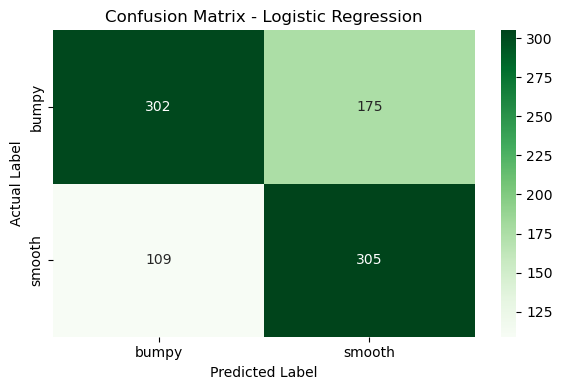

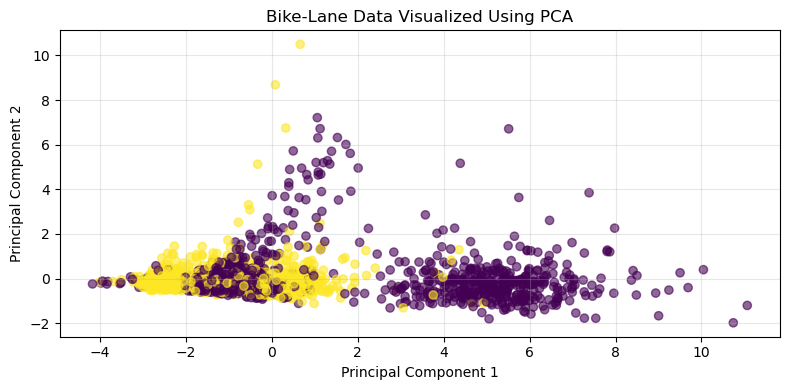

,accuracy,f1_score,recall_score
0,0.68,0.68,0.63


In [94]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_df = build_supervised_model(lr_model, "Logistic Regression")
display(lr_df)

2. k-Nearest Neighbors (k-NN)

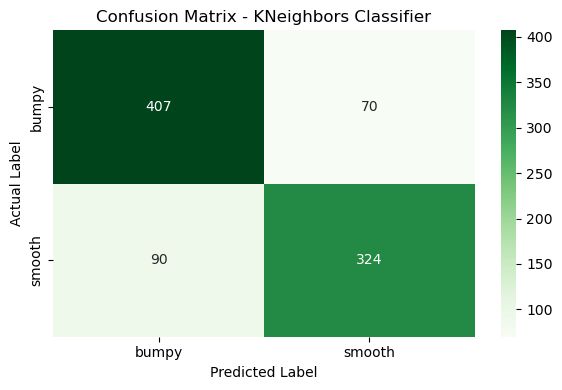

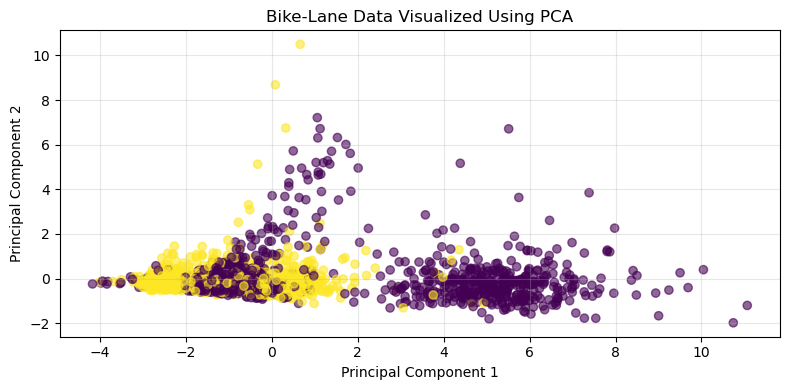

,accuracy,f1_score,recall_score
0,0.82,0.84,0.85


In [95]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_df = build_supervised_model(knn_model, "KNeighbors Classifier")
display(knn_df)

3. Random Forest Classifier

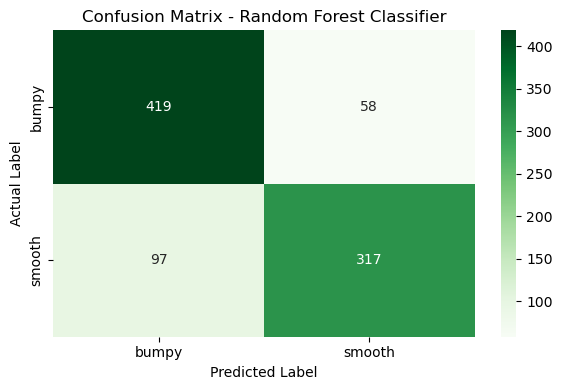

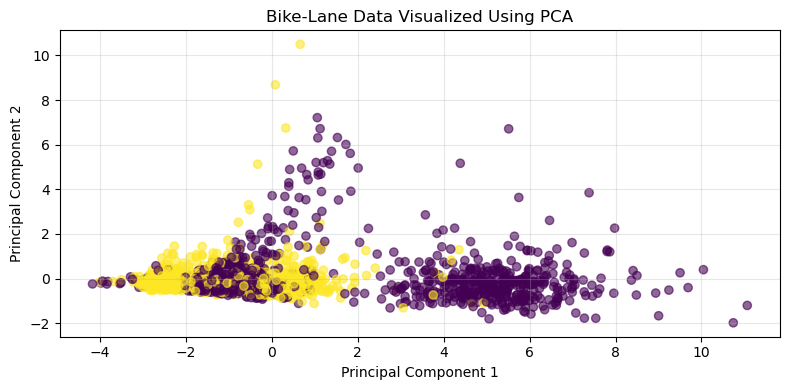

,accuracy,f1_score,recall_score
0,0.83,0.84,0.88


In [96]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=50, criterion='entropy', max_depth=10)
rf_df = build_supervised_model(rf_model, "Random Forest Classifier")
display(rf_df)

4. Support Vector Classifier

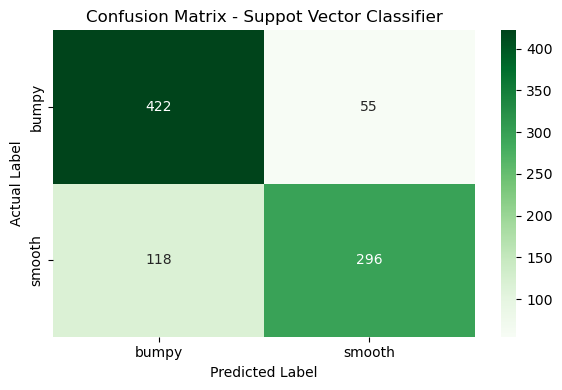

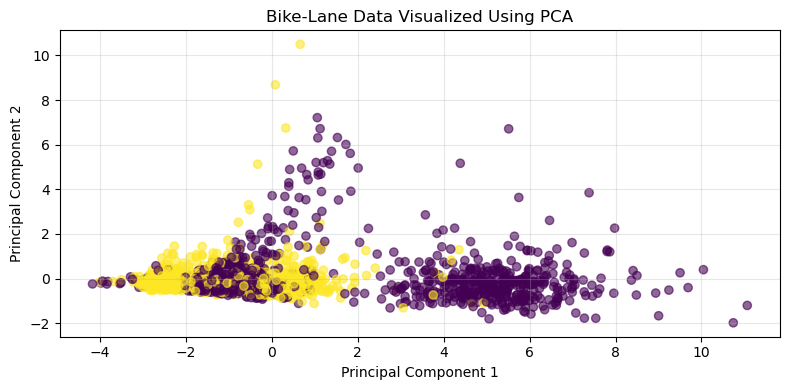

,accuracy,f1_score,recall_score
0,0.81,0.83,0.88


In [97]:
from sklearn.svm import SVC
svc_model = SVC(kernel='rbf')
svc_df = build_supervised_model(svc_model, 'Suppot Vector Classifier')
display(svc_df)

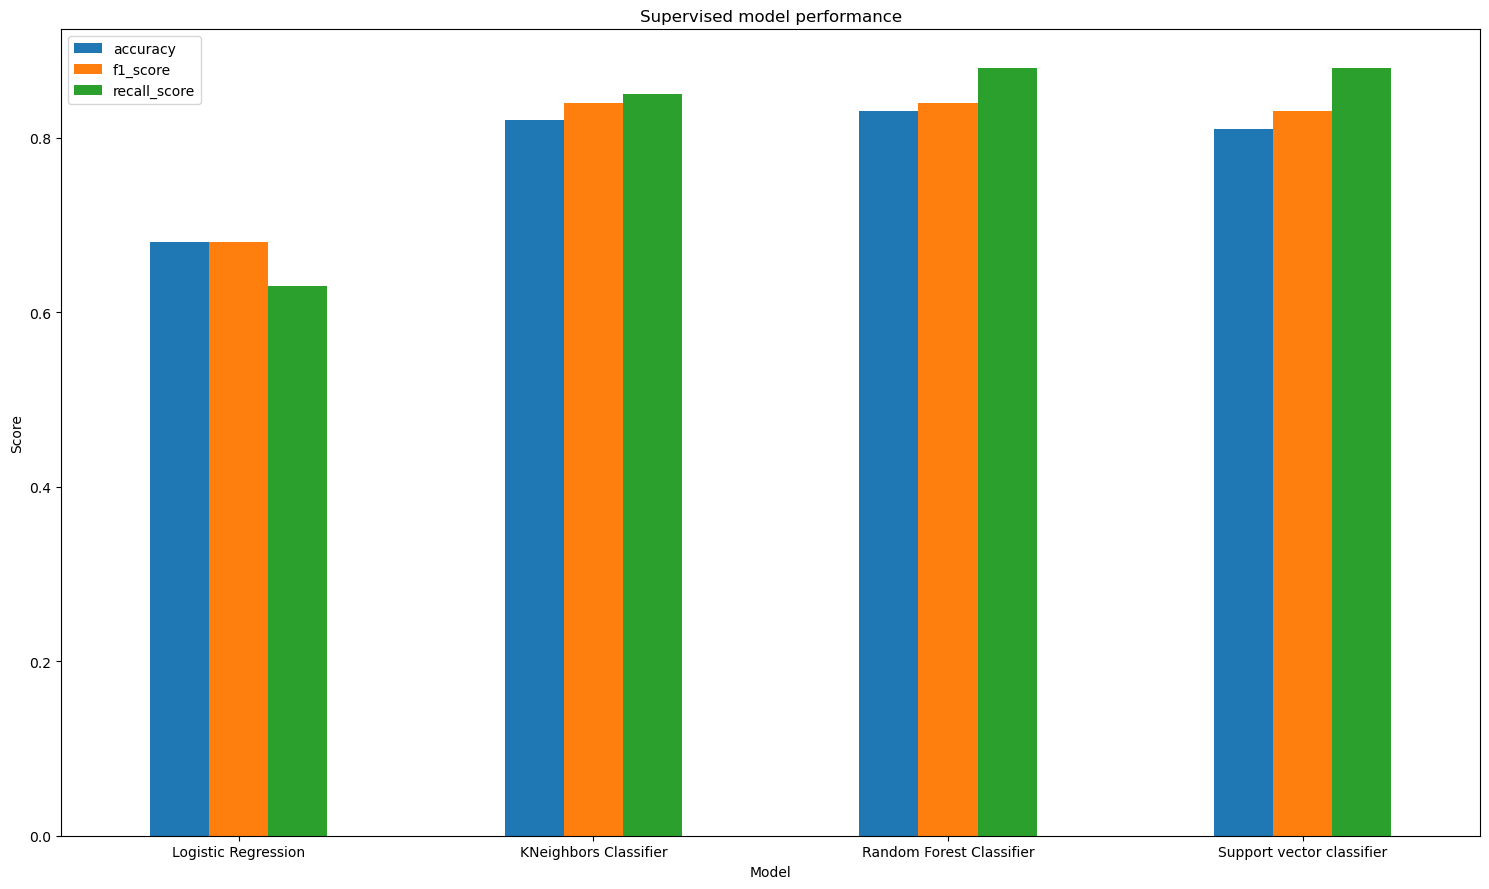

,accuracy,f1_score,recall_score
Logistic Regression,0.68,0.68,0.63
KNeighbors Classifier,0.82,0.84,0.85
Random Forest Classifier,0.83,0.84,0.88
Support vector classifier,0.81,0.83,0.88


In [116]:
#Visulaization of all models validation by mean
lr_mean = lr_df[['accuracy', 'f1_score', 'recall_score']].mean() 
knn_mean = knn_df[['accuracy', 'f1_score', 'recall_score']].mean() 
rf_mean = rf_df[['accuracy', 'f1_score', 'recall_score']].mean() 
svc_mean = svc_df[['accuracy', 'f1_score', 'recall_score']].mean() 

Total_mean = pd.DataFrame({
    'Logistic Regression':lr_mean,
    'KNeighbors Classifier':knn_mean,
    'Random Forest Classifier':rf_mean,
    'Support vector classifier':svc_mean
}).T #Transpose (models are rows and values are columns)

axes = Total_mean.plot(kind='bar', figsize=(15,9))

plt.title('Supervised model performance')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(Total_mean.round(2))


# Unsupervised Learning

1. Agglomerative Clustering

In [100]:
from sklearn.cluster import AgglomerativeClustering

X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.3, random_state=42)

y_test = y_test.reset_index(drop = True)

sc = StandardScaler()
X_train_scag = sc.fit_transform(X_train)
X_test_scag = sc.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pcaag = pca.fit_transform(X_train_scag)
X_test_pcaag = pca.transform(X_test_scag)

model_ac = AgglomerativeClustering(n_clusters=2, linkage='ward') #'ward' linkage minimizes the variance of merged clusters
clusters = model_ac.fit_predict(X_test_pcaag)

#Check if the true values are aligned with clusters
cls_result = pd.crosstab(y_test, clusters)

#If cluster 0 has most of the actual bumpy windows
if cls_result.loc['bumpy', 0] > cls_result.loc['bumpy', 1]:
    #If yes then cluster 0 is bumpy and cluster 1 is smooth
    y_pred_ag = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    #If not then cluster 0 is smooth and cluster 1 is bumpy
    y_pred_ag = ['smooth' if c == 0 else 'bumpy' for c in clusters]

#Different types of validation of a model
ari_ag = adjusted_rand_score(y_test, clusters)
nmi_ag = normalized_mutual_info_score(y_test, clusters)
silhouette_ag = silhouette_score(X_test_pcaag, clusters)

agc_df = pd.DataFrame({
    "ARI": [ari_ag],
    "NMI": [nmi_ag],
    "Silhouette Score": [silhouette_ag]
    })

display(agc_df.round(4))    

,ARI,NMI,Silhouette Score
0,0.0782,0.1787,0.7125


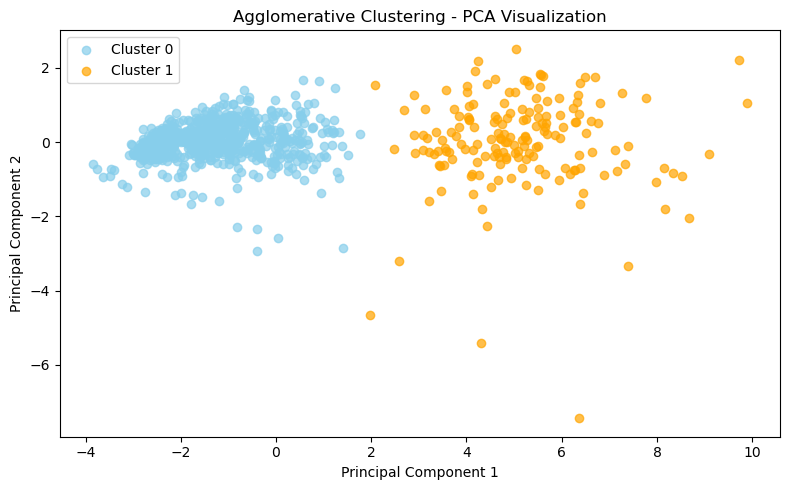

In [110]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_pcaag[clusters == 0, 0],
    X_test_pcaag[clusters == 0, 2],
    color="skyblue",
    label="Cluster 0",
    alpha=0.7
)

plt.scatter(
    X_test_pcaag[clusters == 1, 0],
    X_test_pcaag[clusters == 1, 2],
    color="orange",
    label="Cluster 1",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Agglomerative Clustering - PCA Visualization")

plt.legend()
plt.tight_layout()
plt.show()

2. K means Clustering

In [105]:
from sklearn.cluster import KMeans

X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.3, random_state=42)

y_test = y_test.reset_index(drop = True)

sc = StandardScaler()
X_train_sckm = sc.fit_transform(X_train)
X_test_sckm = sc.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pcakm = pca.fit_transform(X_train_sckm)
X_test_pcakm = pca.transform(X_test_sckm)

model_km = KMeans(n_clusters=2, random_state=42)
model_km.fit(X_train_pcakm)
clusters = model_km.predict(X_test_pcakm)

#Check if the true values are aligned with clusters
cls_result = pd.crosstab(y_test, clusters)

#If cluster 0 has most of the actual bumpy windows
if cls_result.loc['bumpy', 0] > cls_result.loc['bumpy', 1]:
    #If yes then cluster 0 is bumpy and cluster 1 is smooth
    y_pred_km = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    #If not then cluster 0 is smooth and cluster 1 is bumpy
    y_pred_km = ['smooth' if c == 0 else 'bumpy' for c in clusters]

#Different types of validation of a model
ari_km = adjusted_rand_score(y_test, clusters)
nmi_km = normalized_mutual_info_score(y_test, clusters)
silhouette_km = silhouette_score(X_test_pcaag, clusters)

km_df = pd.DataFrame({
    "ARI": [ari_km],
    "NMI": [nmi_km],
    "Silhouette Score": [silhouette_km]
    })

display(km_df.round(4))    

c:\Users\Himanshu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


,ARI,NMI,Silhouette Score
0,0.0808,0.1853,0.7138


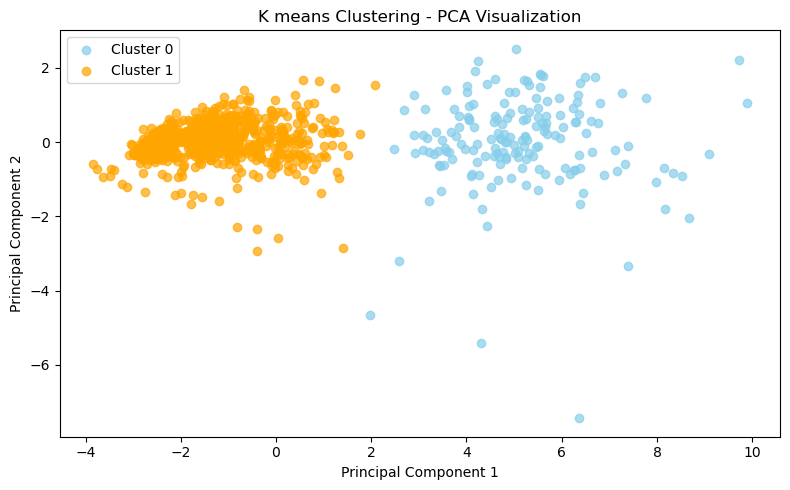

In [107]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_pcakm[clusters == 0, 0],
    X_test_pcakm[clusters == 0, 2],
    color="skyblue",
    label="Cluster 0",
    alpha=0.7
)

plt.scatter(
    X_test_pcakm[clusters == 1, 0],
    X_test_pcakm[clusters == 1, 2],
    color="orange",
    label="Cluster 1",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K means Clustering - PCA Visualization")

plt.legend()
plt.tight_layout()
plt.show()

3. Fuzzy C-Means Clustering

In [108]:
import skfuzzy as fuzz

X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.3, random_state=42)

y_test = y_test.reset_index(drop = True)

sc = StandardScaler()
X_train_scfc = sc.fit_transform(X_train)
X_test_scfc = sc.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pcafc = pca.fit_transform(X_train_scfc)
X_test_pcafc = pca.transform(X_test_scfc)

cntr, u_train,_,_,_,_,_ = fuzz.cluster.cmeans(X_train_pcafc.T,2,m=2, error=0.005, maxiter=1000)

u_test,_,_,_,_,_= fuzz._cluster.cmeans_predict(X_test_pcafc.T, cntr,2,error=0.005, maxiter=1000)

clusters = np.argmax(u_test, axis=0)

cls_result = pd.crosstab(y_test, clusters)

#If cluster 0 has most of the actual bumpy windows
if cls_result.loc['bumpy', 0] > cls_result.loc['bumpy', 1]:
    #If yes then cluster 0 is bumpy and cluster 1 is smooth
    y_pred_fc = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    #If not then cluster 0 is smooth and cluster 1 is bumpy
    y_pred_fc = ['smooth' if c == 0 else 'bumpy' for c in clusters]

#Different types of validation of a model
ari_fc = adjusted_rand_score(y_test, clusters)
nmi_fc = normalized_mutual_info_score(y_test, clusters)
silhouette_fc = silhouette_score(X_test_pcaag, clusters)

fc_df = pd.DataFrame({
    "ARI": [ari_fc],
    "NMI": [nmi_fc],
    "Silhouette Score": [silhouette_fc]
    })

display(fc_df.round(4))  

,ARI,NMI,Silhouette Score
0,0.0821,0.1866,0.714


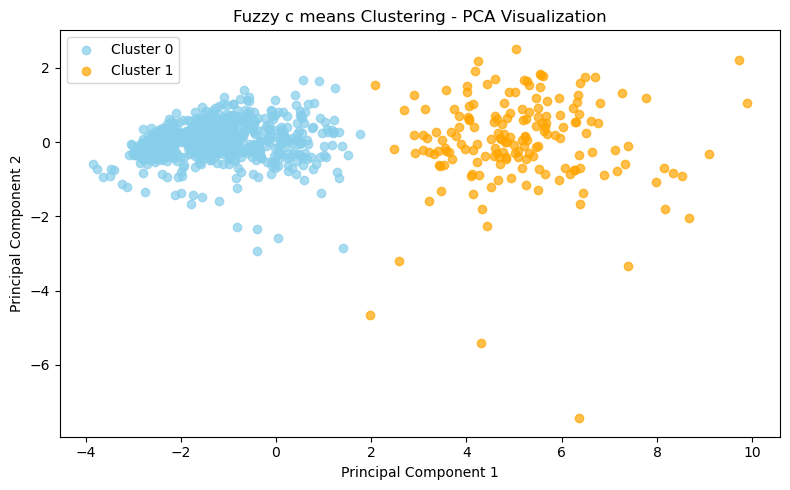

In [109]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_pcakm[clusters == 0, 0],
    X_test_pcakm[clusters == 0, 2],
    color="skyblue",
    label="Cluster 0",
    alpha=0.7
)

plt.scatter(
    X_test_pcakm[clusters == 1, 0],
    X_test_pcakm[clusters == 1, 2],
    color="orange",
    label="Cluster 1",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Fuzzy c means Clustering - PCA Visualization")

plt.legend()
plt.tight_layout()
plt.show()

4. Gaussian Mixture Model

In [111]:
from sklearn.mixture import GaussianMixture

X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.3, random_state=42)

y_test = y_test.reset_index(drop = True)

sc = StandardScaler()
X_train_scgm = sc.fit_transform(X_train)
X_test_scgm = sc.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pcagm = pca.fit_transform(X_train_scgm)
X_test_pcagm = pca.transform(X_test_scgm)

model_gmm = GaussianMixture(n_components=2, random_state=42)
model_gmm.fit(X_train_pcagm)

clusters = model_gmm.predict(X_test_pcagm)

cls_result = pd.crosstab(y_test, clusters)

#If cluster 0 has most of the actual bumpy windows
if cls_result.loc['bumpy', 0] > cls_result.loc['bumpy', 1]:
    #If yes then cluster 0 is bumpy and cluster 1 is smooth
    y_pred_gm = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    #If not then cluster 0 is smooth and cluster 1 is bumpy
    y_pred_gm = ['smooth' if c == 0 else 'bumpy' for c in clusters]

#Different types of validation of a model
ari_gm = adjusted_rand_score(y_test, clusters)
nmi_gm = normalized_mutual_info_score(y_test, clusters)
silhouette_gm = silhouette_score(X_test_pcaag, clusters)

gm_df = pd.DataFrame({
    "ARI": [ari_gm],
    "NMI": [nmi_gm],
    "Silhouette Score": [silhouette_gm]
    })

display(gm_df.round(4))  




c:\Users\Himanshu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


,ARI,NMI,Silhouette Score
0,0.0785,0.137,0.6564


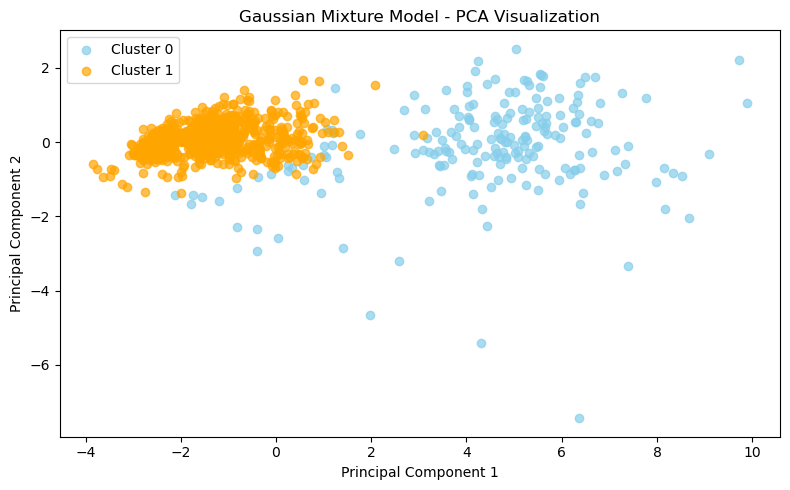

In [112]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_pcakm[clusters == 0, 0],
    X_test_pcakm[clusters == 0, 2],
    color="skyblue",
    label="Cluster 0",
    alpha=0.7
)

plt.scatter(
    X_test_pcakm[clusters == 1, 0],
    X_test_pcakm[clusters == 1, 2],
    color="orange",
    label="Cluster 1",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Gaussian Mixture Model - PCA Visualization")

plt.legend()
plt.tight_layout()
plt.show()

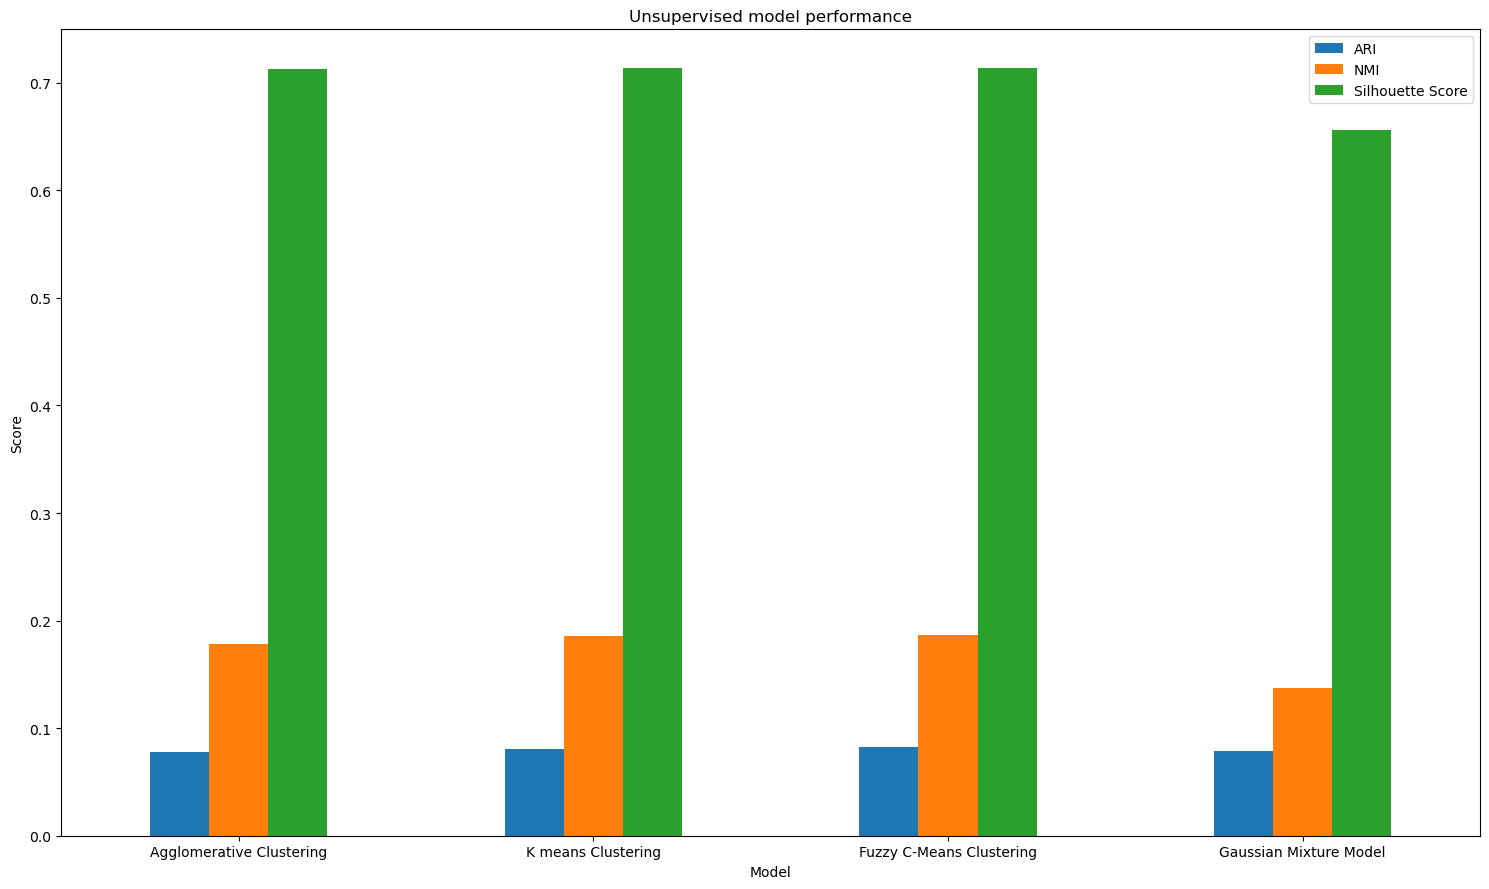

,ARI,NMI,Silhouette Score
Agglomerative Clustering,0.0782,0.1787,0.7125
K means Clustering,0.0808,0.1853,0.7138
Fuzzy C-Means Clustering,0.0821,0.1866,0.7140
Gaussian Mixture Model,0.0785,0.1370,0.6564


In [122]:
agc = agc_df[['ARI', 'NMI', 'Silhouette Score']].iloc[0]
km = km_df[['ARI', 'NMI', 'Silhouette Score']].iloc[0]
fc = fc_df[['ARI', 'NMI', 'Silhouette Score']].iloc[0]
gm = gm_df[['ARI', 'NMI', 'Silhouette Score']].iloc[0]

Total_ = pd.DataFrame({
    'Agglomerative Clustering':agc,
    'K means Clustering':km,
    'Fuzzy C-Means Clustering':fc,
    'Gaussian Mixture Model':gm
}).T #Transpose (models are rows and values are columns)

axes = Total_.plot(kind='bar', figsize=(15,9))

plt.title('Unsupervised model performance')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(Total_.round(4))

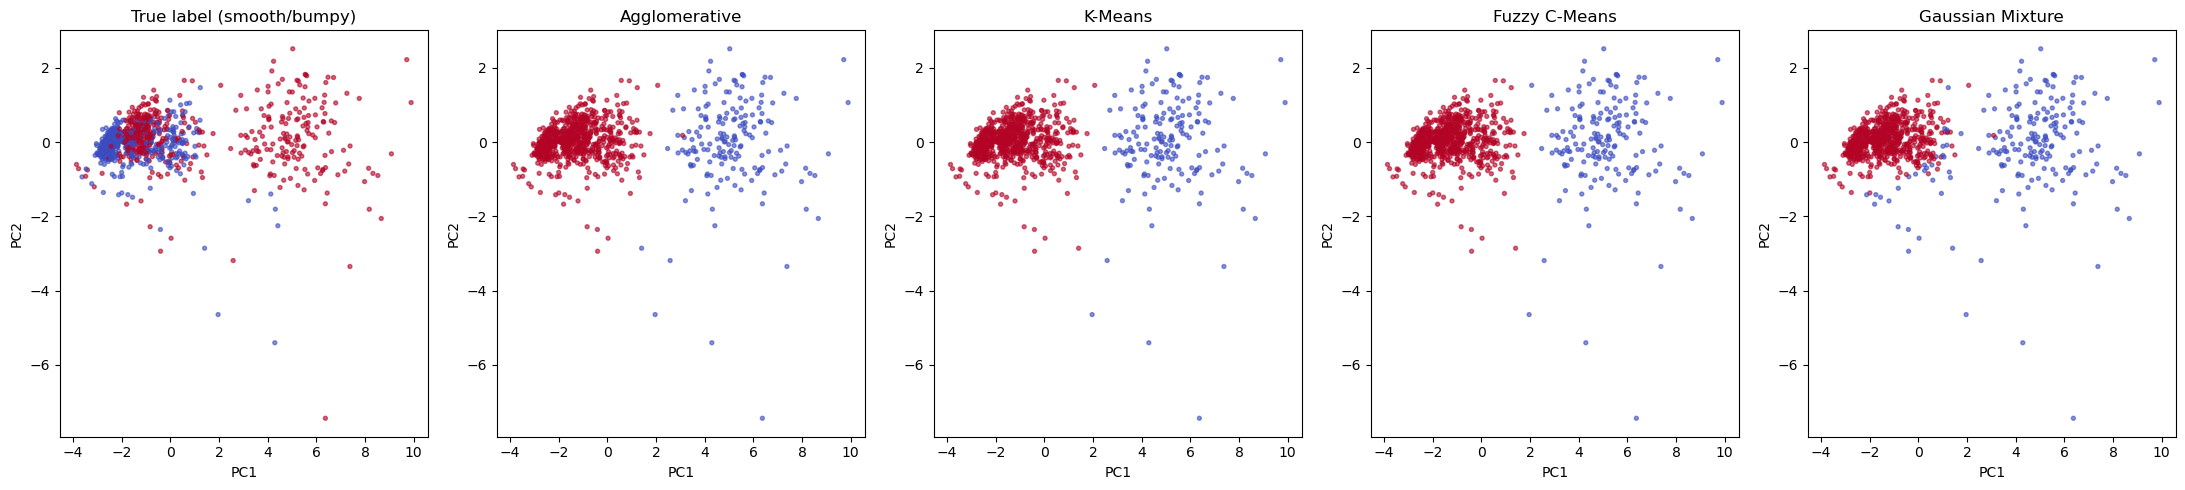

In [125]:
import matplotlib.pyplot as plt
import numpy as np

# Convert the true string labels to 0 (smooth) and 1 (bumpy) for coloring
y_true_num = [1 if label == 'bumpy' else 0 for label in y_test]

results = [
    ('Agglomerative', [1 if p == 'bumpy' else 0 for p in y_pred_ag]),
    ('K-Means', [1 if p == 'bumpy' else 0 for p in y_pred_km]),
    ('Fuzzy C-Means', [1 if p == 'bumpy' else 0 for p in y_pred_fc]),
    ('Gaussian Mixture', [1 if p == 'bumpy' else 0 for p in y_pred_gm])
]

# 3. Select your PCA data (since the splits and PCA settings were identical, any of your test PCAs will work)
X_pca = X_test_pcakm 

# 4. Your plotting code (updated for consistent colors)
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

# Plot True Labels
axes[0].scatter(X_pca[:, 0], X_pca[:, 2], c=y_true_num, cmap='coolwarm', s=8, alpha=0.6)
axes[0].set_title('True label (smooth/bumpy)')

# Plot Predicted Labels
for ax, (name, labels) in zip(axes[1:], results):
    # Changed cmap to 'coolwarm' so the colors match the True Label chart exactly
    ax.scatter(X_pca[:, 0], X_pca[:, 2], c=labels, cmap='coolwarm', s=8, alpha=0.6)
    ax.set_title(name)

# Apply axes labels
for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

# Deployment

Random Forest Model Deployment

In [ ]:
def extract_window_features(window):
    """Extract statistical features from one sensor window."""

    features = {}

    for sensor in ["acc", "gyro", "grav"]:
        magnitude = np.sqrt(
            window[f"{sensor}_x"]**2
            + window[f"{sensor}_y"]**2
            + window[f"{sensor}_z"]**2
        )

        values = magnitude.to_numpy()

        features[f"{sensor}_std"] = np.std(values)
        features[f"{sensor}_mean"] = np.mean(values)
        features[f"{sensor}_rms"] = np.sqrt(np.mean(values**2))
        features[f"{sensor}_min"] = np.min(values)
        features[f"{sensor}_max"] = np.max(values)

    return features


def extract_recording_features(df, window_size, step_size):
    """Create windows and extract features from each window."""

    windows_data = create_window(df, window_size, step_size)

    features = [
        extract_window_features(window)
        for window in windows_data
    ]

    return pd.DataFrame(features)



# Load external sensor recording
df_external = load_and_merge(
    "data_raw/external_data/Accelerometer.csv",
    "data_raw/external_data/Gravity.csv",
    "data_raw/external_data/Gyroscope.csv"
)

# Use the same window settings as training
Sampling_freq = 100
windows = 2
steps = 1

window_size = Sampling_freq * windows
step_size = Sampling_freq * steps

# Extract features from all windows
X_external = extract_recording_features(
    df_external, window_size, step_size
)

if X_external.empty:
    raise ValueError("No windows were created from the recording.")

# Match the feature names and order used to fit the scaler
if hasattr(sc, "feature_names_in_"):
    expected_features = list(sc.feature_names_in_)

    missing = [
        feature for feature in expected_features
        if feature not in X_external.columns
    ]

    if missing:
        raise ValueError(
            f"Missing training features: {missing}"
        )

    X_external = X_external[expected_features]

elif X_external.shape[1] != sc.n_features_in_:
    raise ValueError(
        "External feature count does not match the fitted scaler."
    )

# Apply the previously fitted preprocessing steps
X_external_scaled = sc.transform(X_external)
X_external_pca = pca.transform(X_external_scaled)

predictions = rf_model.predict(X_external_pca)

# Display predictions for each window
results = pd.DataFrame({
    "Window": np.arange(1, len(predictions) + 1),
    "Predicted_Class": predictions
})

print("Prediction counts:")
display(results["Predicted_Class"].value_counts().to_frame("Count"))

Prediction counts:


,Count
Predicted_Class,
smooth,671
bumpy,347


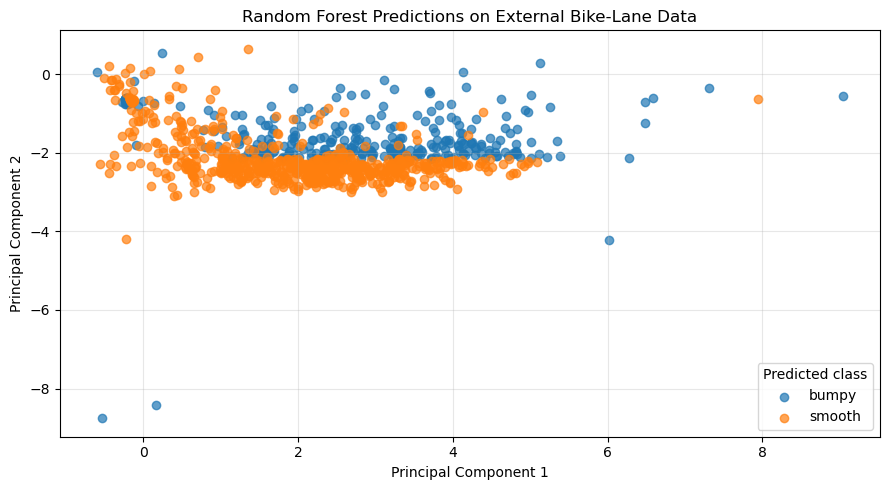

In [ ]:
if X_external_pca.shape[1] >= 2:
    plt.figure(figsize=(9, 5))

    for label in pd.unique(predictions):
        mask = predictions == label

        plt.scatter(
            X_external_pca[mask, 1],
            X_external_pca[mask, 2],
            label=str(label),
            alpha=0.7
        )

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("Random Forest Predictions on External Bike-Lane Data")
    plt.legend(title="Predicted class")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("At least two PCA components are required for this plot.")

Gaussian Mixture Model Deployment

In [135]:
# Load external sensor recording
df_external = load_and_merge(
    "data_raw/external_data/Accelerometer.csv",
    "data_raw/external_data/Gravity.csv",
    "data_raw/external_data/Gyroscope.csv"
)

# Create windows using the same settings as training
Sampling_freq = 100
windows = 2
steps = 1

window_size = Sampling_freq * windows
step_size = Sampling_freq * steps

# Extract features using the existing method
X_external = extract_recording_features(
    df_external, window_size, step_size
)

if X_external.empty:
    raise ValueError("No windows were created from the recording.")

# Match the features used to fit the scaler
if hasattr(sc, "feature_names_in_"):
    expected_features = list(sc.feature_names_in_)

    missing = [
        feature for feature in expected_features
        if feature not in X_external.columns
    ]

    if missing:
        raise ValueError(f"Missing training features: {missing}")

    X_external = X_external[expected_features]

elif X_external.shape[1] != sc.n_features_in_:
    raise ValueError("External feature count does not match the scaler.")

# Apply the fitted preprocessing pipeline
X_external_scaled = sc.transform(X_external)
X_external_pca = pca.transform(X_external_scaled)

# Predict clusters using the trained GMM
gmm_predictions = model_gmm.predict(X_external_pca)

# Get probabilities for each cluster
gmm_probabilities = model_gmm.predict_proba(X_external_pca)

# Store results
results_gmm = pd.DataFrame({
    "Window": np.arange(1, len(gmm_predictions) + 1),
    "Predicted_Cluster": gmm_predictions
})

for cluster in range(gmm_probabilities.shape[1]):
    results_gmm[f"Cluster_{cluster}_Probability"] = (
        gmm_probabilities[:, cluster]
    )

print("Cluster counts:")
display(
    results_gmm["Predicted_Cluster"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

Cluster counts:


,Count
Predicted_Cluster,
0,828
1,190


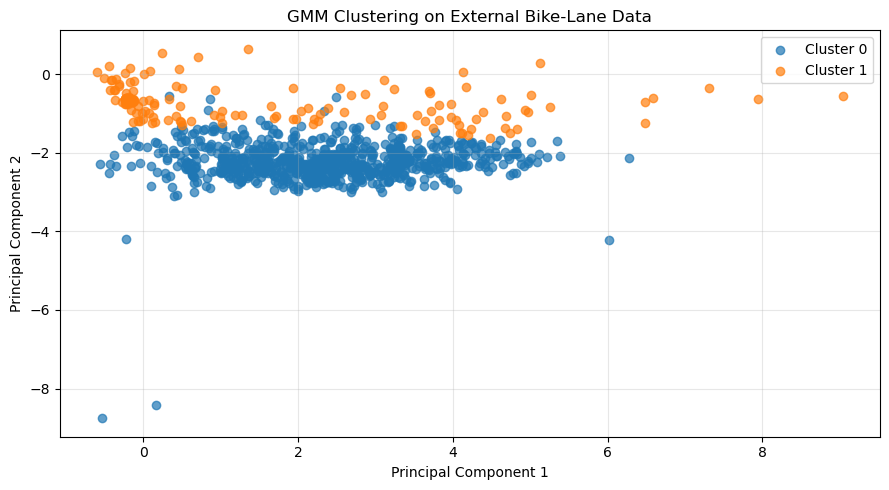

In [138]:
if X_external_pca.shape[1] >= 2:
    plt.figure(figsize=(9, 5))

    for cluster in np.unique(gmm_predictions):
        mask = gmm_predictions == cluster

        plt.scatter(
            X_external_pca[mask, 1],
            X_external_pca[mask, 2],
            label=f"Cluster {cluster}",
            alpha=0.7
        )

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("GMM Clustering on External Bike-Lane Data")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("At least two PCA components are required for plotting.")